# Benchmark comparison
This notebook compares model results across benchmark CSVs in `runs/benchmarks/`

In [10]:
import os
import glob
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')


In [11]:
# Load all benchmark summary CSVs
files = sorted(glob.glob('../runs/benchmarks/summary*.csv'))
if not files:
    raise FileNotFoundError('No summary*.csv files found')

def dataset_label_from_path(path):
    name = os.path.basename(path).replace('summary_', '').replace('.csv', '')
    return name if name else 'default'

def try_parse_dict(x):
    if pd.isna(x):
        return None
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return None
    return None

dfs = []
for f in files:
    df = pd.read_csv(f)
    df['dataset_label'] = dataset_label_from_path(f)
    dfs.append(df)

bench = pd.concat(dfs, ignore_index=True)

# Normalize numeric columns
num_cols = ['train_time_sec', 'map50', 'map50_95', 'precision', 'recall', 'f1', 'epochs', 'imgsz', 'batch']
for c in num_cols:
    if c in bench.columns:
        bench[c] = pd.to_numeric(bench[c], errors='coerce')

bench['train_time_min'] = bench.get('train_time_sec') / 60.0

# Parse per-class dicts for later use
for c in ['per_class_ap50_95', 'per_class_ap50', 'per_class_precision', 'per_class_recall', 'per_class_f1']:
    if c in bench.columns:
        bench[c] = bench[c].apply(try_parse_dict)

bench.head(10)


,model,train_time_sec,inf_time_per_frame_ms,preprocess_time_per_frame_ms,postprocess_time_per_frame_ms,total_time_per_frame_ms,eval_split,num_classes,map50,map50_95,precision,recall,f1,per_class_ap50_95,per_class_ap50,per_class_precision,per_class_recall,per_class_f1,eval_imgsz,eval_batch,eval_rect,eval_half,eval_workers,eval_device,eval_dnn,epochs,imgsz,batch,dataset,config_device,fixed_input_inference_ms,fixed_input_shape,fixed_input_dtype,fixed_input_device,fixed_input_iters,fixed_input_warmup,train_results_dir,eval_results_dir,dataset_label,train_time_min
0,yolov8s.pt,123.93,2.278,0.872,2.355,5.505,val,80,0.821085,0.648244,0.861387,0.712956,0.780175,"{'person': 0.652907205105288, 'bicycle': 0.314...","{'person': 0.8502572652490359, 'bicycle': 0.46...","{'person': 0.9499520789951584, 'bicycle': 1.0,...","{'person': 0.6725529244199498, 'bicycle': 0.29...","{'person': 0.7875390799316359, 'bicycle': 0.45...",640,16,0.0,0.0,8,0,0.0,50,640.0,16,coco128.yaml,0,5.669,640x640,torch.float32,cuda:0,200,20,/workspace/repo/2d-detector-benchmark/runs/det...,/workspace/repo/2d-detector-benchmark/runs/det...,coco128,2.065500
1,yolo11s.pt,132.92,2.743,0.752,5.001,8.497,val,80,0.821031,0.647823,0.866558,0.729363,0.792063,"{'person': 0.6402644013569698, 'bicycle': 0.39...","{'person': 0.846469556010127, 'bicycle': 0.677...","{'person': 0.93903768037665, 'bicycle': 0.8402...","{'person': 0.6670893438336636, 'bicycle': 0.33...","{'person': 0.7800404583137359, 'bicycle': 0.47...",640,16,0.0,0.0,8,0,0.0,50,640.0,16,coco128.yaml,0,7.749,640x640,torch.float32,cuda:0,200,20,/workspace/repo/2d-detector-benchmark/runs/det...,/workspace/repo/2d-detector-benchmark/runs/det...,coco128,2.215333
2,yolov8s.pt,12904.86,1.870,0.409,0.344,2.623,test,1,0.978601,0.814210,0.975842,0.932494,0.953676,{'person': 0.8142098554868685},{'person': 0.9786006853105178},{'person': 0.9758415871715655},{'person': 0.9324940608147998},{'person': 0.9536755080729636},640,16,0.0,0.0,8,0,0.0,50,640.0,16,/workspace/data/fisheye-dataset/data.yaml,0,5.307,640x640,torch.float32,cuda:0,200,20,/workspace/repo/2d-detector-benchmark/runs/det...,/workspace/repo/2d-detector-benchmark/runs/det...,fisheye,215.081000
3,yolo11s.pt,14540.28,1.919,0.445,0.390,2.754,test,1,0.974265,0.807932,0.979681,0.930744,0.954586,{'person': 0.80793185170083},{'person': 0.9742651344344185},{'person': 0.9796806805904377},{'person': 0.9307441607821836},{'person': 0.9545856535612498},640,16,0.0,0.0,8,0,0.0,50,640.0,16,/workspace/data/fisheye-dataset/data.yaml,0,6.090,640x640,torch.float32,cuda:0,200,20,/workspace/repo/2d-detector-benchmark/runs/det...,/workspace/repo/2d-detector-benchmark/runs/det...,fisheye,242.338000
4,faster-rcnn_r50_fpn_fisheye,20532.02,29.391,NaN,NaN,29.391,test,1,0.965000,0.744000,NaN,NaN,NaN,{'person': 0.744},{'person': 0.965},None,None,None,1333x800,1,NaN,NaN,2,0,NaN,12,NaN,2,/workspace/data/fisheye-dataset-coco-format/an...,0,29.391,800x1333,torch.float32,cuda:0,200,20,/workspace/repo/mmdetection/runs/benchmarks/ag...,/workspace/repo/mmdetection/runs/benchmarks/ag...,fisheye_mmdet,342.200333
5,faster-rcnn_r50_fpn_dcn_fisheye,27316.60,34.280,NaN,NaN,34.280,test,1,0.973000,0.754000,NaN,NaN,NaN,{'person': 0.754},{'person': 0.973},None,None,None,1333x800,1,NaN,NaN,2,0,NaN,12,NaN,2,/workspace/data/fisheye-dataset-coco-format/an...,0,34.280,800x1333,torch.float32,cuda:0,200,20,/workspace/repo/mmdetection/runs/benchmarks/ag...,/workspace/repo/mmdetection/runs/benchmarks/ag...,fisheye_mmdet,455.276667
6,yolov8s.pt,2543.10,1.965,0.540,0.736,3.241,val,8,0.904416,0.671776,0.899089,0.838137,0.867544,"{'car': 0.8043416126953223, 'van': 0.753764116...","{'car': 0.967135499496115, 'van': 0.9401336349...","{'car': 0.9285841187719769, 'van': 0.924196324...","{'car': 0.9258244409952013, 'van': 0.900668615...","{'car': 0.9272022264468232, 'van': 0.912280800...",640,16,0.0,0.0,8,0,0.0,50,640.0,16,/workspace/data/kitti-dataset/data.yaml,0,5.777,640x640,torch.float32,cuda:0,200,20,/workspace/repo/2d-detector-b

In [ ]:
# take care of weights of each class by how many samples they have in the dataset

In [12]:
# Enrich with person AP50-95 if available
bench['person_ap50_95'] = bench['per_class_ap50_95'].apply(lambda d: d.get('person') or (d.get('pedestrian') + d.get('Person_sitting') + d.get('cyclist')) / 3 if isinstance(d, dict) else None)

In [13]:
# Overview table
cols = ['dataset_label', 'model', 'eval_split', 'map50_95', 'map50', 'precision', 'recall', 'f1', 'train_time_min']
available = [c for c in cols if c in bench.columns]
bench[available].sort_values(['dataset_label', 'map50_95'], ascending=[True, False])

,dataset_label,model,eval_split,map50_95,map50,precision,recall,f1,train_time_min
0,coco128,yolov8s.pt,val,0.648244,0.821085,0.861387,0.712956,0.780175,2.065500
1,coco128,yolo11s.pt,val,0.647823,0.821031,0.866558,0.729363,0.792063,2.215333
2,fisheye,yolov8s.pt,test,0.814210,0.978601,0.975842,0.932494,0.953676,215.081000
3,fisheye,yolo11s.pt,test,0.807932,0.974265,0.979681,0.930744,0.954586,242.338000
5,fisheye_mmdet,faster-rcnn_r50_fpn_dcn_fisheye,test,0.754000,0.973000,NaN,NaN,NaN,455.276667
4,fisheye_mmdet,faster-rcnn_r50_fpn_fisheye,test,0.744000,0.965000,NaN,NaN,NaN,342.200333
7,kitti,yolo11s.pt,val,0.707219,0.924739,0.923303,0.853856,0.887223,48.431000
6,kitti,yolov8s.pt,val,0.671776,0.904416,0.899089,0.838137,0.867544,42.385000
8,zedrgb,yolov8s.pt,test,0.855239,0.990318,0.990311,0.970760,0.980438,76.239667
9,zedrgb,yolo11s.pt,test,0.848490,0.984450,0.985793,0.973872,0.979796,85.982667


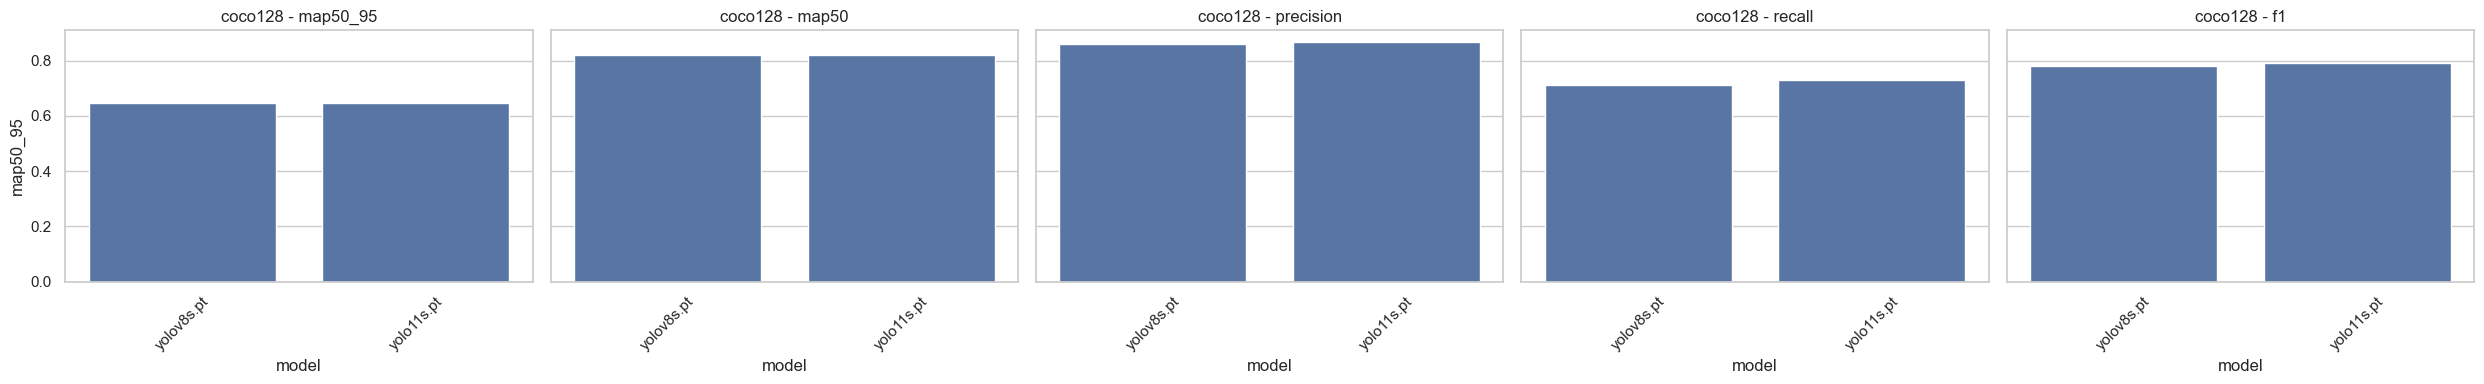

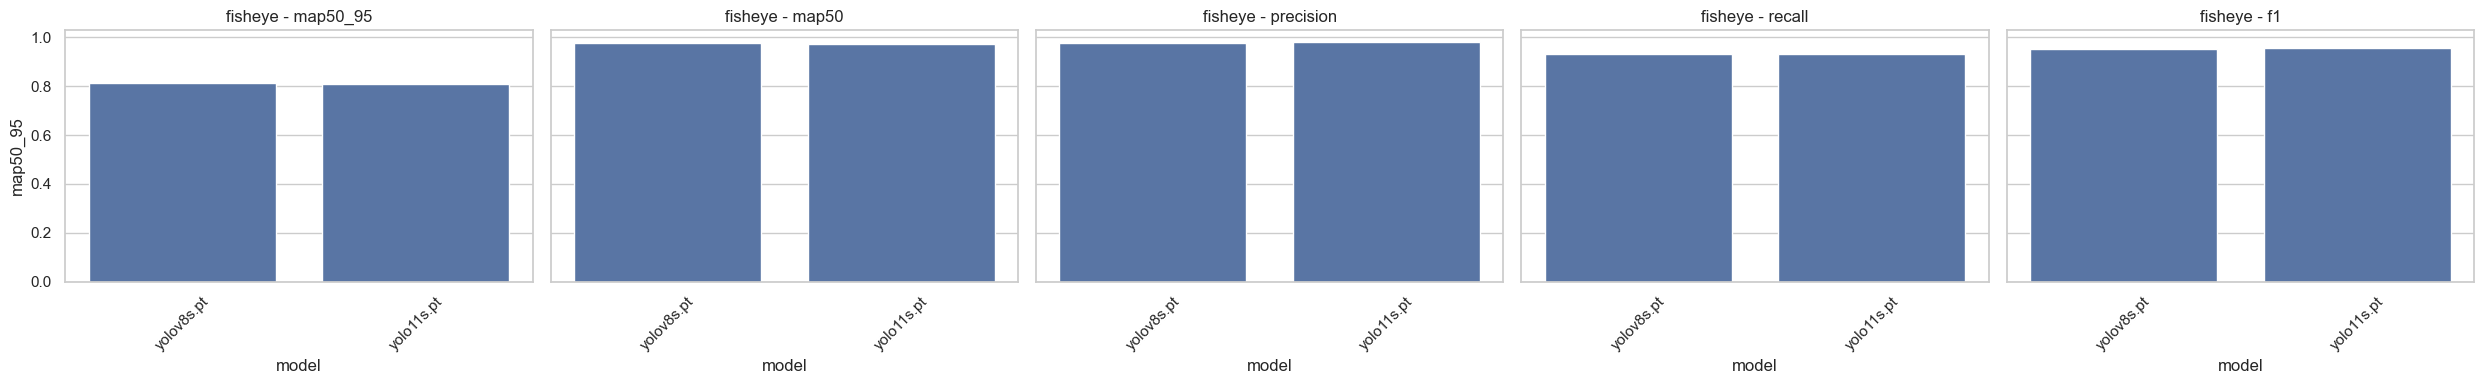

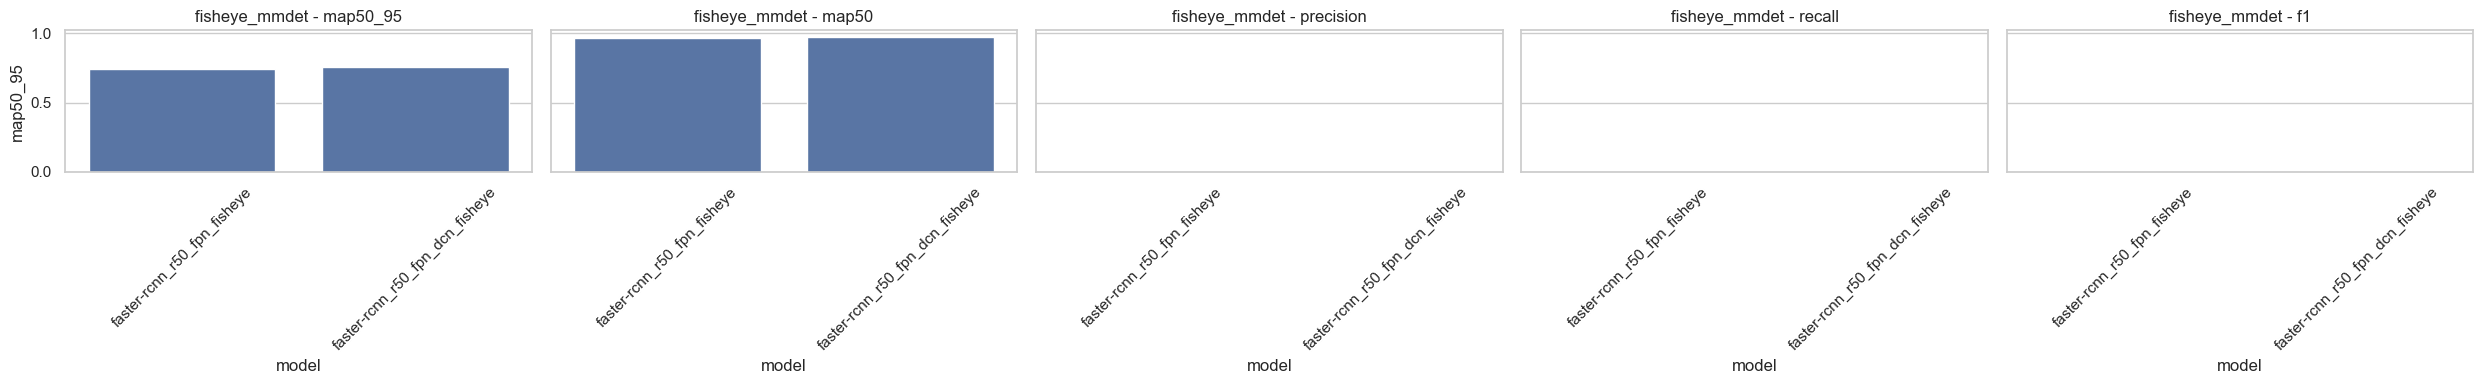

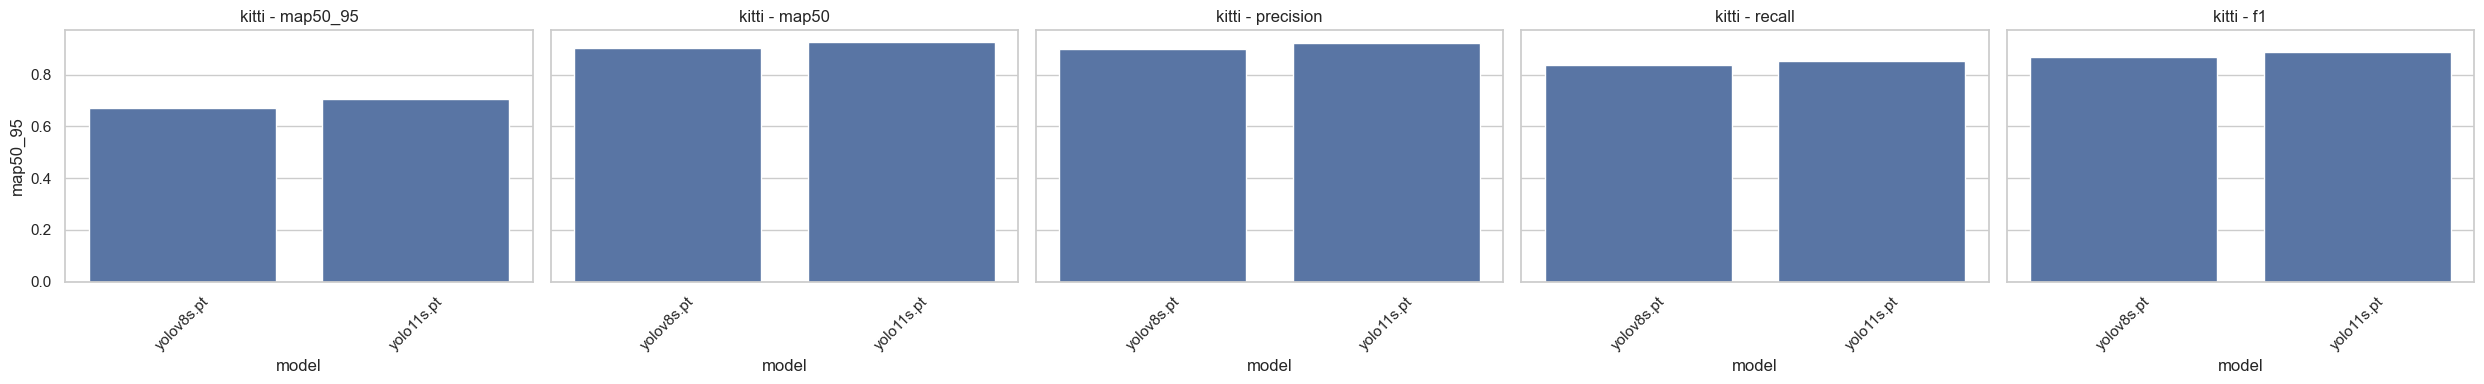

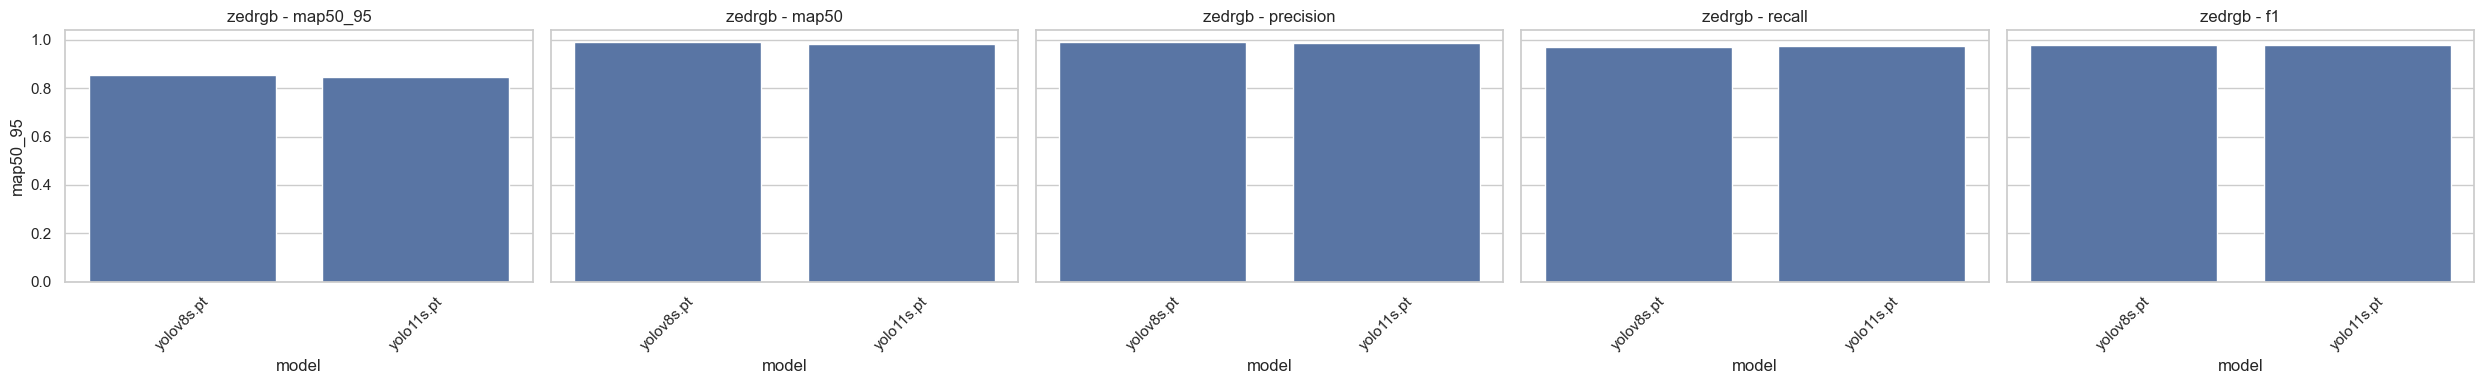

In [14]:
# Metric comparison plots per dataset
metrics = ['map50_95', 'map50', 'precision', 'recall', 'f1']
datasets = bench['dataset_label'].dropna().unique()
for ds in datasets:
    sub = bench[bench['dataset_label'] == ds]
    if sub.empty:
        continue
    fig, axes = plt.subplots(1, len(metrics), figsize=(5*len(metrics), 4), sharey=True)
    if len(metrics) == 1:
        axes = [axes]
    for ax, m in zip(axes, metrics):
        if m not in sub.columns:
            ax.axis('off')
            continue
        sns.barplot(data=sub, x='model', y=m, ax=ax)
        ax.set_title(f'{ds} - {m}')
        ax.set_xlabel('model')
        ax.set_ylabel(m)
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


### Note: not sure if this is strictly fair to compare modes on different sized datasets

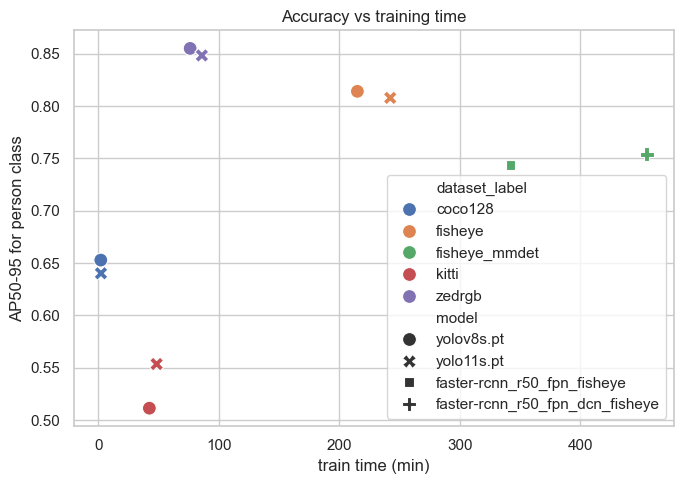

In [15]:
# Efficiency: map50_95 vs train time
if 'train_time_min' in bench.columns:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=bench, x='train_time_min', y='person_ap50_95', hue='dataset_label', style='model', s=100)
    plt.xlabel('train time (min)')
    plt.ylabel('AP50-95 for person class')
    plt.title('Accuracy vs training time')
    plt.tight_layout()
    plt.show()


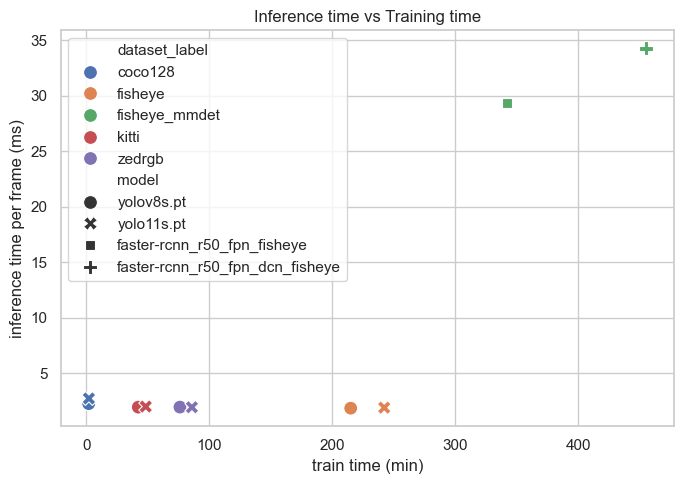

In [16]:
# Efficiency: map50_95 vs train time
if 'train_time_min' in bench.columns:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=bench, x='train_time_min', y='inf_time_per_frame_ms', hue='dataset_label', style='model', s=100)
    plt.xlabel('train time (min)')
    plt.ylabel('inference time per frame (ms)')
    plt.title('Inference time vs Training time')
    plt.tight_layout()
    plt.show()


In [17]:
print("AP50-95 for 'person' class in coco128 dataset:")
print(f"YOLOv8s.pt: {bench[bench['dataset_label'] == 'coco128']['per_class_ap50_95'].iloc[0]['person']}")
print(f"YOLO11s.pt: {bench[bench['dataset_label'] == 'coco128']['per_class_ap50_95'].iloc[1]['person']}")

AP50-95 for 'person' class in coco128 dataset:
YOLOv8s.pt: 0.652907205105288
YOLO11s.pt: 0.6402644013569698


In [18]:
# Optional: per-class breakdown for a specific dataset + model
def show_top_classes(df, dataset_label, model, metric='per_class_ap50_95', top_n=10):
    sub = df[(df['dataset_label'] == dataset_label) & (df['model'] == model)]
    if sub.empty:
        print('No matching row')
        return
    d = sub.iloc[0].get(metric)
    if not isinstance(d, dict):
        print(f'No per-class dict for {metric}')
        return
    s = pd.Series(d).sort_values(ascending=False)
    display(s.head(top_n))

# Example:
show_top_classes(bench, dataset_label='coco128', model='yolov8s.pt', metric='per_class_ap50_95', top_n=10)


banana          0.995000
fork            0.995000
sheep           0.965803
bench           0.952155
cell phone      0.945222
fire hydrant    0.921100
cake            0.920781
orange          0.908301
train           0.907071
toaster         0.906382
dtype: float64